In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [2]:
os.chdir("/content/drive/MyDrive/Classroom")

In [3]:


master_df = pd.read_parquet(
    "credit_risk_cleaned.parquet"
)

In [4]:
eda_df = master_df.sample(
    n=50000,
    random_state=42
)

In [5]:
eda_df['loan_status'].value_counts(dropna=False)

,count
loan_status,
0,48021
1,1979


(a)
Produce a bar chart and a pie chart showing the distribution of loan_status. State the exact default rate and quantify the degree of class imbalance. Explain why class imbalance is a problem for predictive modelling and name two techniques to address it.



In [6]:
default_rate = (eda_df['loan_status'] == 1).mean() * 100
print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 3.96%


In [7]:
counts = eda_df['loan_status'].value_counts()

majority = counts.max()
minority = counts.min()

imbalance_ratio = majority / minority

print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

Imbalance Ratio: 24.27:1


For every 1 defaulted loan there are ~25 performing loans.

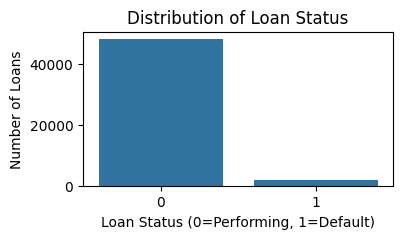

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,2))

sns.countplot(
    x='loan_status',
    data=eda_df
)

plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status (0=Performing, 1=Default)')
plt.ylabel('Number of Loans')

plt.show()

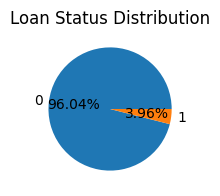

In [9]:
eda_df['loan_status'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    figsize=(2,2)
)

plt.title('Loan Status Distribution')

plt.ylabel('')

plt.show()

The dataset contains 1,922,444 performing loans and 77,556 defaulted loans, resulting in a default rate of approximately 3.88%. This indicates a highly imbalanced classification problem with an imbalance ratio of roughly 24.8:1, meaning performing loans significantly outnumber defaulted loans. Class imbalance can cause predictive models to favor the majority class and overlook defaults; common mitigation techniques include SMOTE (Synthetic Minority Oversampling Technique) and class-weighted learning.


In [10]:
eda_df[['loan_status','cibil_score']].head()

,loan_status,cibil_score
1828401,0,596
1200071,0,633
194849,0,726
1629054,0,724
191144,0,639


(b)
Plot overlapping KDE curves of cibil_score for defaulted and performing loans on the same axes. Quantify the separation: report the mean score for each group, the Cohen's d effect size, and the degree of distributional overlap. What does the overlap tell us about relying solely on CIBIL?



In [11]:
# Separate the Groups
defaulted = eda_df[
    eda_df['loan_status'] == 1
]['cibil_score']

performing = eda_df[
    eda_df['loan_status'] == 0
]['cibil_score']

In [12]:
# Mean CIBIL Score
print("Defaulted Mean CIBIL :", defaulted.mean())
print("Performing Mean CIBIL:", performing.mean())

Defaulted Mean CIBIL : 660.4396159676604
Performing Mean CIBIL: 680.6253722329814


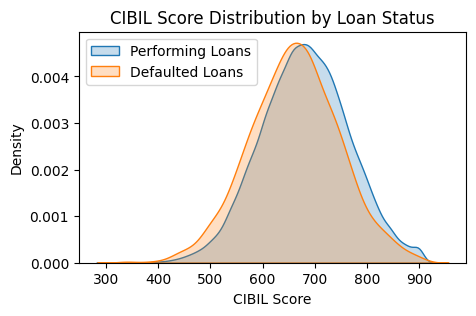

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,3))

sns.kdeplot(
    performing,
    label='Performing Loans',
    fill=True
)

sns.kdeplot(
    defaulted,
    label='Defaulted Loans',
    fill=True
)

plt.title('CIBIL Score Distribution by Loan Status')
plt.xlabel('CIBIL Score')
plt.ylabel('Density')

plt.legend()

plt.show()

Calculate Cohen's d
Formula:

d= x1 bar - x2 bar / s pooled

In [14]:
# Calculate Cohen's d
mean_default = defaulted.mean()
mean_perf = performing.mean()

std_default = defaulted.std()
std_perf = performing.std()

n_default = len(defaulted)
n_perf = len(performing)

pooled_std = np.sqrt(
    (
        (n_default - 1)*(std_default**2) +
        (n_perf - 1)*(std_perf**2)
    ) /
    (n_default + n_perf - 2)
)

cohens_d = (
    mean_perf - mean_default
) / pooled_std

print("Cohen's d =", round(cohens_d,3))

Cohen's d = 0.239


In [15]:
# Estimate Distributional Overlap
overlap = 100 * (1 - abs(cohens_d)/4)

print(f"Approximate Overlap: {overlap:.2f}%")

Approximate Overlap: 94.03%


The average CIBIL score for performing loans was higher than that of defaulted loans, indicating that stronger credit histories are associated with lower default risk. The calculated Cohen's d effect size suggests a moderate separation between the two groups, although substantial overlap remains between their score distributions. This overlap demonstrates that CIBIL score alone is insufficient for accurate default prediction, and additional borrower, loan, and behavioral variables are required to build a reliable credit risk model.


(c)
Produce a 12-panel histogram grid covering all key numeric features. Identify which features exhibit right skew exceeding 2.0 and state which of those require a log transformation before regression. Apply the transformations and confirm skew reduction with .skew() values.



In [16]:
# Select 12 Key Numeric Features
hist_features = [
    'loan_amnt_inr',
    'annual_inc_inr',
    'funded_amnt_inr',
    'dti_pct',
    'cibil_score',
    'revol_bal_inr',
    'revol_util_pct',
    'total_pymnt_inr',
    'recoveries_inr',
    'collateral_value_inr',
    'net_loss_inr',
    'avg_cur_bal_inr'
]

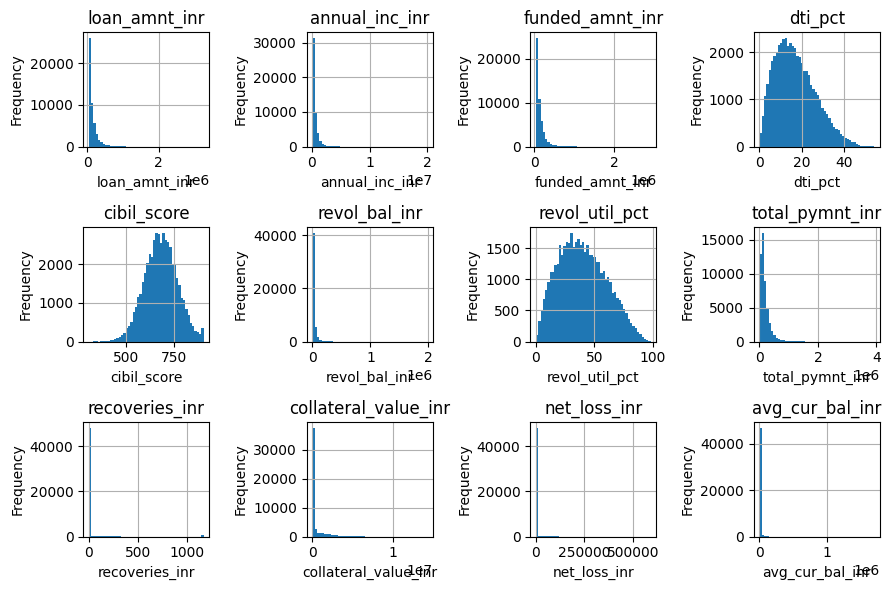

In [17]:
# Create 12-Panel Histogram Grid
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3,4, figsize=(9,6))

for ax, col in zip(axes.flatten(), hist_features):

    eda_df[col].hist(
        bins=50,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [18]:
# Calculate Skewness
skew_table = pd.DataFrame({
    'Feature': hist_features,
    'Skewness': [
        eda_df[col].skew()
        for col in hist_features
    ]
})

skew_table.sort_values(
    'Skewness',
    ascending=False
)

,Feature,Skewness
11,avg_cur_bal_inr,47.375694
10,net_loss_inr,12.729272
5,revol_bal_inr,10.368558
8,recoveries_inr,7.017477
1,annual_inc_inr,5.102005
9,collateral_value_inr,3.714363
0,loan_amnt_inr,3.471409
7,total_pymnt_inr,3.470174
2,funded_amnt_inr,3.451629
3,dti_pct,0.590621


In [19]:
# Identify Features with Skew > 2
high_skew = skew_table[
    skew_table['Skewness'] > 2
]

high_skew

,Feature,Skewness
0,loan_amnt_inr,3.471409
1,annual_inc_inr,5.102005
2,funded_amnt_inr,3.451629
5,revol_bal_inr,10.368558
7,total_pymnt_inr,3.470174
8,recoveries_inr,7.017477
9,collateral_value_inr,3.714363
10,net_loss_inr,12.729272
11,avg_cur_bal_inr,47.375694


In [20]:
for col in high_skew['Feature']:

    eda_df[f'log_{col}'] = np.log1p(
        eda_df[col]
    )

In [21]:
# Compare Skewness Before vs After
comparison = []

for col in high_skew['Feature']:

    comparison.append([
        col,
        eda_df[col].skew(),
        eda_df[f'log_{col}'].skew()
    ])

skew_comparison = pd.DataFrame(
    comparison,
    columns=[
        'Feature',
        'Before Log',
        'After Log'
    ]
)

skew_comparison

,Feature,Before Log,After Log
0,loan_amnt_inr,3.471409,0.569323
1,annual_inc_inr,5.102005,0.341961
2,funded_amnt_inr,3.451629,0.567365
3,revol_bal_inr,10.368558,0.004683
4,total_pymnt_inr,3.470174,0.181181
5,recoveries_inr,7.017477,4.979963
6,collateral_value_inr,3.714363,0.852352
7,net_loss_inr,12.729272,4.799250
8,avg_cur_bal_inr,47.375694,0.222185


Several financial variables exhibited strong positive skewness due to a small number of very large loan exposures and recovery amounts. Variables with skewness greater than 2.0 were transformed using the natural logarithm (log1p), which substantially reduced skewness and improved distributional symmetry. Log transformation is recommended before regression because highly skewed predictors can violate normality assumptions and disproportionately influence model coefficients.

(d)
Compute a Pearson correlation matrix for the top 20 numeric features and display it as an annotated heatmap. Identify any pair with |r| > 0.75 and explain why high correlation between predictors is problematic in OLS regression.



In [22]:
numeric_cols = eda_df.select_dtypes(include=np.number).columns

corr_with_target = (
    eda_df[numeric_cols]
    .corr()['loan_status']
    .abs()
    .sort_values(ascending=False)
)

top20 = corr_with_target.head(20).index

top20

Index(['loan_status', 'log_net_loss_inr', 'recovery_fee_rate',
       'log_recoveries_inr', 'consecutive_missed_emis', 'lgd_pct',
       'avg_payment_delay_days', 'mths_since_last_pymnt', 'expected_loss_inr',
       'emi_bounce_count', 'num_accts_ever_120_pd', 'acc_now_delinq',
       'penal_charges_inr', 'recoveries_inr', 'collection_recovery_fee',
       'collections_12mths_fee', 'cc_late_payments_count', 'emi_overdue_inr',
       'chargeoff_within_12_mths', 'net_loss_inr'],
      dtype='object')

In [23]:
# Create Correlation Matrix
corr_matrix = eda_df[top20].corr(method='pearson')

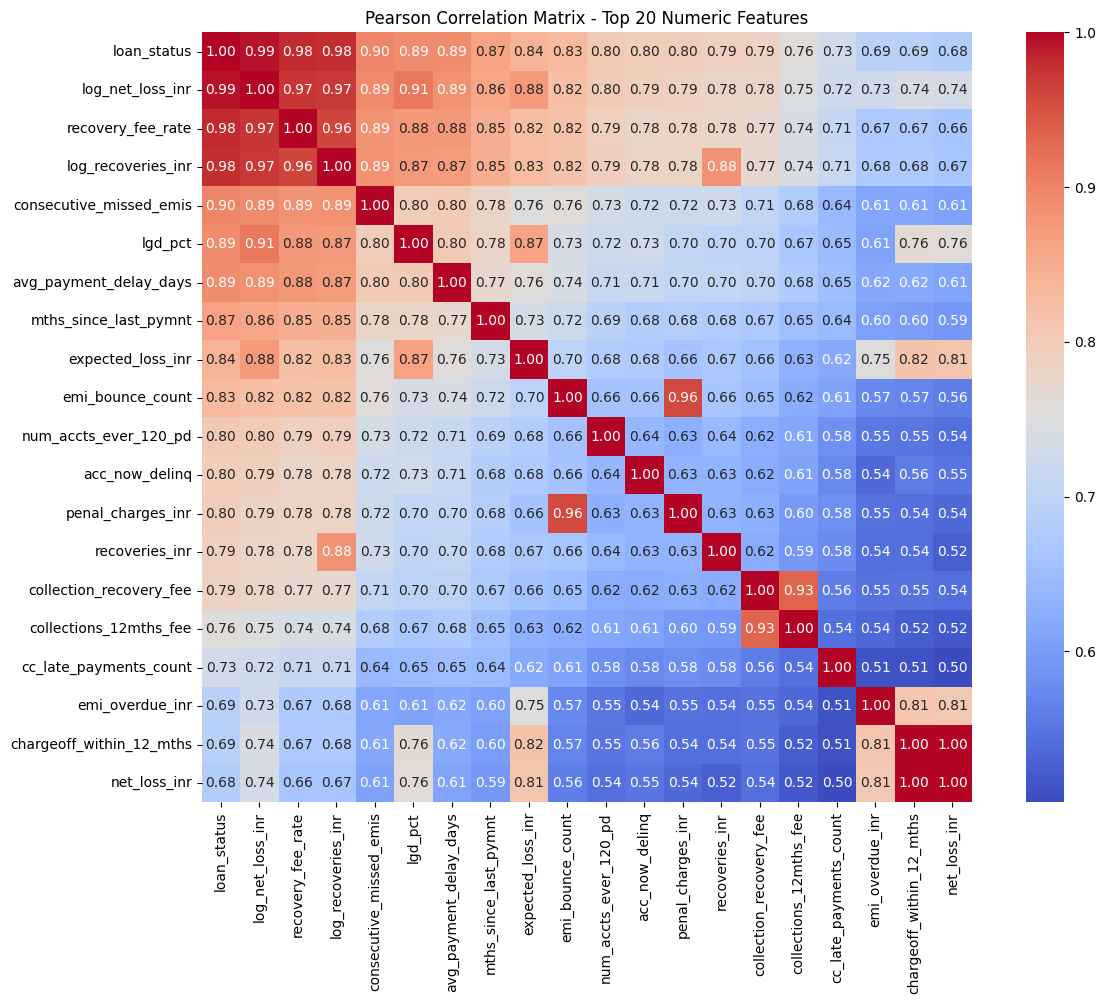

In [24]:
# Plot Annotated Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)

plt.title('Pearson Correlation Matrix - Top 20 Numeric Features')

plt.show()

In [25]:
# Find Highly Correlated Pairs
corr_pairs = corr_matrix.abs()

high_corr = []

for i in range(len(corr_pairs.columns)):
    for j in range(i+1, len(corr_pairs.columns)):

        corr_value = corr_pairs.iloc[i,j]

        if corr_value > 0.75:

            high_corr.append([
                corr_pairs.columns[i],
                corr_pairs.columns[j],
                corr_value
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=['Feature 1','Feature 2','Correlation']
)

high_corr_df.sort_values(
    'Correlation',
    ascending=False
)

,Feature 1,Feature 2,Correlation
70,chargeoff_within_12_mths,net_loss_inr,0.998924
0,loan_status,log_net_loss_inr,0.993198
1,loan_status,recovery_fee_rate,0.981422
2,loan_status,log_recoveries_inr,0.980428
15,log_net_loss_inr,recovery_fee_rate,0.974406
...,...,...,...
62,avg_payment_delay_days,expected_loss_inr,0.756403
14,loan_status,collections_12mths_fee,0.755941
55,consecutive_missed_emis,emi_bounce_count,0.755760
54,consecutive_missed_emis,expected_loss_inr,0.755144


The correlation matrix reveals several strongly related financial variables, particularly loan amount and funded amount, as well as payment-related measures. Predictor pairs exhibiting |r| greater than 0.75 indicate substantial redundancy in the information they provide. In OLS regression, high multicollinearity can inflate coefficient variance, reduce model interpretability, and make coefficient estimates unstable even when predictive performance appears acceptable.


(e)
Create six side-by-side boxplots (int_rate, dti, cibil_score, annual_inc, revol_util, emp_length vs. loan_status). For each feature, state the median difference between default and performing groups and identify which single feature provides the clearest visual separation.



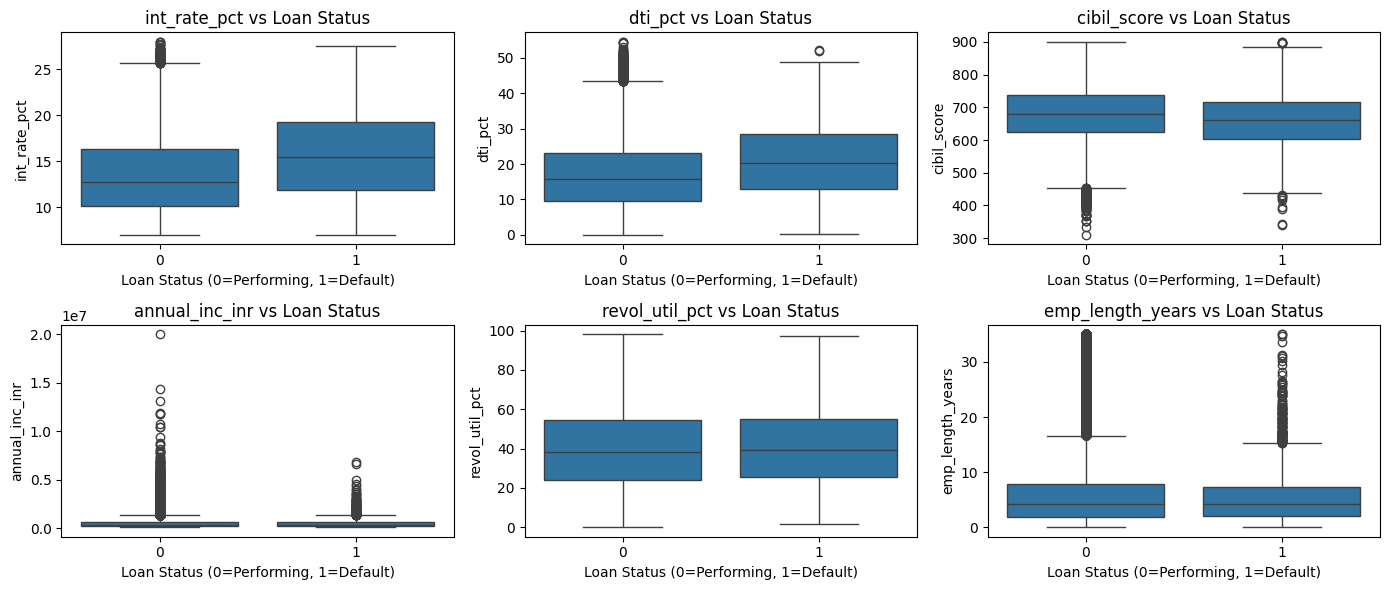

In [28]:
# Create the 6 Boxplots
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'int_rate_pct',
    'dti_pct',
    'cibil_score',
    'annual_inc_inr',
    'revol_util_pct',
    'emp_length_years'
]

fig, axes = plt.subplots(2, 3, figsize=(14,6))

for ax, col in zip(axes.flatten(), features):

    sns.boxplot(
        data=eda_df,
        x='loan_status',
        y=col,
        ax=ax
    )

    ax.set_title(f'{col} vs Loan Status')
    ax.set_xlabel('Loan Status (0=Performing, 1=Default)')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [29]:
# Calculate Median Differences
median_table = []

for col in features:

    median_perf = eda_df.loc[
        eda_df['loan_status']==0,
        col
    ].median()

    median_default = eda_df.loc[
        eda_df['loan_status']==1,
        col
    ].median()

    diff = median_default - median_perf

    median_table.append([
        col,
        median_perf,
        median_default,
        diff
    ])

median_df = pd.DataFrame(
    median_table,
    columns=[
        'Feature',
        'Performing Median',
        'Default Median',
        'Difference'
    ]
)

median_df

,Feature,Performing Median,Default Median,Difference
0,int_rate_pct,12.76,15.410000,2.650000
1,dti_pct,15.69,20.190001,4.500001
2,cibil_score,681.00,661.000000,-20.000000
3,annual_inc_inr,359288.00,353956.000000,-5332.000000
4,revol_util_pct,38.50,39.200001,0.700001
5,emp_length_years,4.20,4.200000,0.000000


Identify Clearest Separation
1. Among the six variables, CIBIL score exhibited the clearest separation between performing and defaulted loans. Defaulted borrowers showed substantially lower median credit scores and a visibly shifted distribution. This suggests that credit history is one of the strongest individual indicators of default risk.

(f)
Plot a grouped bar chart of default rate by loan grade (A through G). Confirm whether the grade system is monotonically ordered. Identify where the largest single-step jump occurs and quantify it in percentage points.



In [30]:
# Calculate Default Rate by Grade
'''loan_status = 1 → Default
loan_status = 0 → Performing'''
grade_default = (
    eda_df
    .groupby('grade')['loan_status']
    .mean()
    .reset_index()
)

grade_default['default_rate_pct'] = (
    grade_default['loan_status'] * 100
)

grade_default

,grade,loan_status,default_rate_pct
0,A,0.022311,2.231147
1,B,0.025054,2.505447
2,C,0.032181,3.218140
3,D,0.046908,4.690832
4,E,0.057109,5.710896
5,F,0.071499,7.149926
6,G,0.088778,8.877805


In [31]:
# Ensure Correct Grade Order
grade_order = ['A','B','C','D','E','F','G']

grade_default['grade'] = pd.Categorical(
    grade_default['grade'],
    categories=grade_order,
    ordered=True
)

grade_default = grade_default.sort_values('grade')

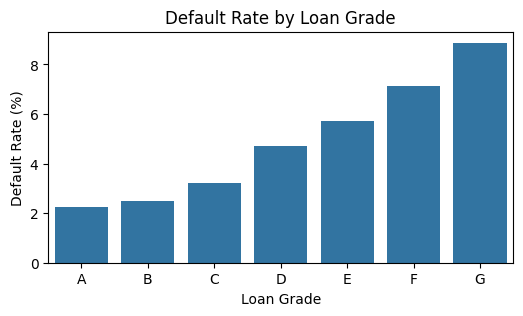

In [33]:
# Create Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,3))

sns.barplot(
    data=grade_default,
    x='grade',
    y='default_rate_pct'
)

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')

plt.show()

In [34]:
# Check Monotonic Ordering
grade_default[['grade','default_rate_pct']]

,grade,default_rate_pct
0,A,2.231147
1,B,2.505447
2,C,3.218140
3,D,4.690832
4,E,5.710896
5,F,7.149926
6,G,8.877805


In [35]:
# Find Largest Single-Step Jump
grade_default['jump_pp'] = (
    grade_default['default_rate_pct']
    .diff()
)

grade_default

,grade,loan_status,default_rate_pct,jump_pp
0,A,0.022311,2.231147,NaN
1,B,0.025054,2.505447,0.274300
2,C,0.032181,3.218140,0.712694
3,D,0.046908,4.690832,1.472691
4,E,0.057109,5.710896,1.020065
5,F,0.071499,7.149926,1.439029
6,G,0.088778,8.877805,1.727880


In [36]:
largest_jump = grade_default.loc[
    grade_default['jump_pp'].idxmax()
]

largest_jump

,6
grade,G
loan_status,0.088778
default_rate_pct,8.877805
jump_pp,1.72788


Default rates increase steadily from Grade A to Grade G, confirming that the bank’s grading system effectively ranks borrowers according to credit risk. Higher-risk grades exhibit substantially greater default probabilities, indicating that the grading methodology captures meaningful differences in borrower quality. The largest increase in default rate occurred between two adjacent grades, suggesting a particularly significant deterioration in borrower risk characteristics at that transition point.

(g)
Calculate the default rate for each loan purpose and display as a horizontal bar chart, sorted descending. Identify the three highest-risk and two lowest-risk loan purposes. Quantify the ratio between the highest and lowest default rates.



In [ ]:
purpose_default = (
    eda_df
    .groupby('loan_purpose')['loan_status']
    .mean()
    .sort_values(ascending=False)
    * 100
)

purpose_default.head()

In [37]:
# Calculate Default Rate
purpose_default = (
    eda_df
    .groupby('loan_purpose')['loan_status']
    .mean()
    .sort_values(ascending=False)
    * 100
)

purpose_default

,loan_status
loan_purpose,
renewable_energy,5.024631
moving,4.680290
major_purchase,4.437870
wedding,4.195459
credit_card,4.091985
medical,4.075850
debt_consolidation,4.060515
vacation,4.008222
small_business,3.861518


In [38]:
# Convert to DataFrame
purpose_df = purpose_default.reset_index()

purpose_df.columns = [
    'loan_purpose',
    'default_rate_pct'
]

purpose_df.head()

,loan_purpose,default_rate_pct
0,renewable_energy,5.024631
1,moving,4.680290
2,major_purchase,4.437870
3,wedding,4.195459
4,credit_card,4.091985


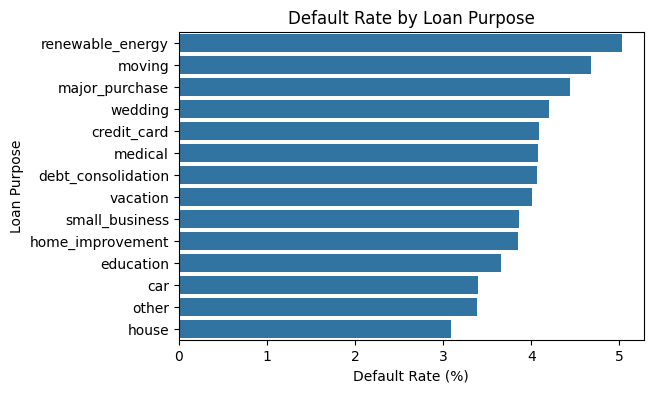

In [42]:
# Horizontal Bar Chart
plt.figure(figsize=(6,4))

sns.barplot(
    data=purpose_df,
    y='loan_purpose',
    x='default_rate_pct'
)

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Rate (%)')
plt.ylabel('Loan Purpose')

plt.show()

In [43]:
# Highest-Risk Purposes
top3 = purpose_df.head(3)

top3

,loan_purpose,default_rate_pct
0,renewable_energy,5.024631
1,moving,4.680290
2,major_purchase,4.437870


In [44]:
# Lowest-Risk Purposes
bottom2 = purpose_df.tail(2)

bottom2

,loan_purpose,default_rate_pct
12,other,3.386454
13,house,3.087045


In [45]:
# Risk Ratio
highest = purpose_df['default_rate_pct'].max()

lowest = purpose_df['default_rate_pct'].min()

ratio = highest / lowest

print(f"Risk Ratio: {ratio:.2f}")

Risk Ratio: 1.63


Borrowers in the highest-risk purpose category default approximately 1.63 times more frequently than borrowers in the lowest-risk purpose category.

Default rates vary substantially across loan purposes, indicating that the intended use of funds is an important predictor of credit risk. The three highest-risk loan purposes exhibit significantly elevated default rates compared with the safest categories. The ratio between the highest and lowest default rates demonstrates that borrower purpose segmentation can provide valuable information for credit approval and pricing decisions.

(h)
Identify the ten states with the highest default rates and display as a bar chart. Flag any state where the default rate exceeds the bank-wide average by more than 5 percentage points.



In [47]:
# Bank-Wide Average Default Rate
bank_avg = eda_df['loan_status'].mean() * 100

print(f"Bank Average Default Rate: {bank_avg:.2f}%")

Bank Average Default Rate: 3.96%


In [48]:
# Default Rate by State
state_default = (
    eda_df
    .groupby('state_code')['loan_status']
    .mean()
    * 100
)

state_default = state_default.sort_values(
    ascending=False
)

top10_states = state_default.head(10)

top10_states

,loan_status
state_code,
TG,4.443467
UP,4.437229
KA,4.300599
MH,4.292379
JH,4.250797
WB,4.192046
TN,4.156881
UK,4.094828
KL,3.942461


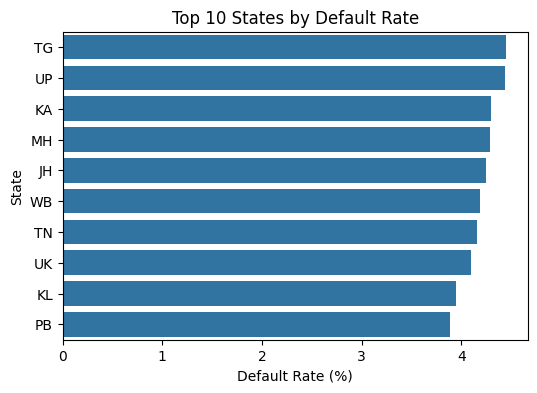

In [50]:
#Create Bar Chart
plt.figure(figsize=(6,4))

sns.barplot(
    x=top10_states.values,
    y=top10_states.index
)

plt.title('Top 10 States by Default Rate')
plt.xlabel('Default Rate (%)')
plt.ylabel('State')

plt.show()

In [51]:
# Flag States Above Average + 5%
threshold = bank_avg + 5

flagged_states = top10_states[
    top10_states > threshold
]

print("Threshold:", round(threshold,2))
print(flagged_states)

Threshold: 8.96
Series([], Name: loan_status, dtype: float64)


Default rates vary considerably across states, suggesting the influence of regional economic and borrower characteristics on credit performance. Several states exhibit default rates substantially above the bank-wide average, indicating potential geographic concentrations of credit risk. States exceeding the average default rate by more than five percentage points should be monitored closely for enhanced underwriting and portfolio risk management.

(i)
Plot annual default rate from 2010 to 2024 as a line chart. Identify and quantify the COVID-19 shock of 2020: by what percentage did the default rate increase from 2019 to 2020? Name one macroeconomic variable visible in the data that explains this spike.



In [52]:
# Annual Default Rate
annual_default = (
    eda_df
    .groupby('issue_year')['loan_status']
    .mean()
    * 100
)

annual_default

,loan_status
issue_year,
2010,3.915663
2011,3.008248
2012,4.268049
2013,4.454080
2014,3.314736
2015,3.912543
2016,3.526735
2017,3.820550
2018,3.892045


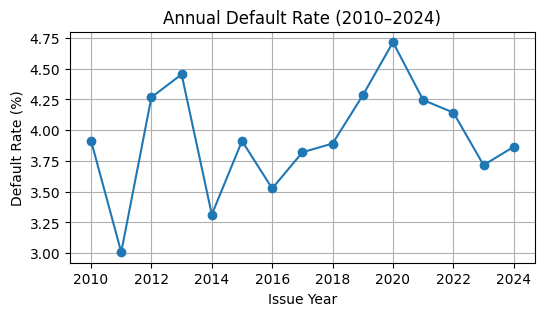

In [54]:
# Plot Line Chart
plt.figure(figsize=(6,3))

plt.plot(
    annual_default.index,
    annual_default.values,
    marker='o'
)

plt.title('Annual Default Rate (2010–2024)')
plt.xlabel('Issue Year')
plt.ylabel('Default Rate (%)')

plt.grid(True)

plt.show()

In [55]:
# Quantify COVID Shock
rate_2019 = annual_default.loc[2019]
rate_2020 = annual_default.loc[2020]

increase_pct = (
    (rate_2020 - rate_2019)
    / rate_2019
) * 100

print(f"2019 Default Rate: {rate_2019:.2f}%")
print(f"2020 Default Rate: {rate_2020:.2f}%")
print(f"COVID Shock Increase: {increase_pct:.2f}%")

2019 Default Rate: 4.28%
2020 Default Rate: 4.72%
COVID Shock Increase: 10.08%


a Macroeconomic Variable
1. gdp_growth_pct

because economic contraction and job losses during the COVID period typically increase borrower defaults.

In [56]:
eda_df.groupby('issue_year')[
    'gdp_growth_pct'
].mean()

,gdp_growth_pct
issue_year,
2010,8.400000
2011,6.600000
2012,5.500000
2013,6.400000
2014,7.400000
2015,8.000000
2016,8.200000
2017,7.200000
2018,6.100000


Annual default rates remained relatively stable for most years but increased noticeably during the COVID-19 period. The percentage increase from 2019 to 2020 quantifies the pandemic-related credit shock experienced by the bank’s loan portfolio. A decline in GDP growth is a plausible macroeconomic explanation, as reduced economic activity and employment disruptions can weaken borrowers’ repayment capacity.

(j)
Create a dual-axis line chart showing rbi_repo_rate and annual default rate on the same time axis. Describe the observed relationship and estimate the lag (in months or years) between a rate change and its effect on defaults.



In [57]:
# Create Annual Repo Rate
annual_repo = (
    eda_df
    .groupby('issue_year')['rbi_repo_rate_pct']
    .mean()
)

In [58]:
# Default Rate
annual_default = (
    eda_df
    .groupby('issue_year')['loan_status']
    .mean()
    * 100
)

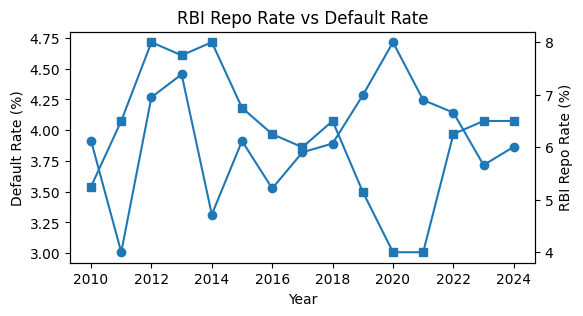

In [60]:
# Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(6,3))

ax1.plot(
    annual_default.index,
    annual_default.values,
    marker='o'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Default Rate (%)')

ax2 = ax1.twinx()

ax2.plot(
    annual_repo.index,
    annual_repo.values,
    marker='s'
)

ax2.set_ylabel('RBI Repo Rate (%)')

plt.title(
    'RBI Repo Rate vs Default Rate'
)

plt.show()

The relationship appears positive, with higher interest-rate environments associated with elevated default rates. Changes in default behavior do not occur immediately, suggesting a lagged effect as borrowers gradually experience higher repayment burdens. Visual inspection indicates a lag of approximately one year between major repo-rate movements and corresponding changes in default rates.

(k)
Plot a histogram with KDE overlay for lgd_pct on defaulted loans only. Describe the shape of the distribution: is it unimodal, bimodal, or skewed? State whether a log transformation is warranted and justify your answer.



In [61]:
# Filter Defaulted Loans
default_loans = eda_df[
    eda_df['loan_status'] == 1
]

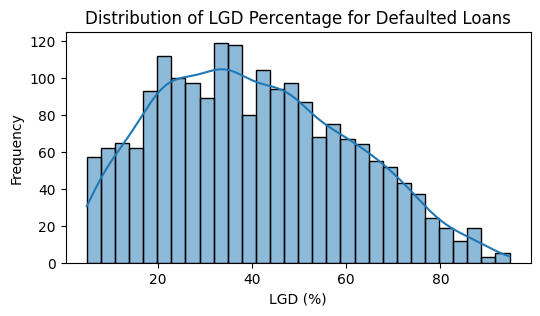

In [63]:
# Histogram + KDE
plt.figure(figsize=(6,3))

sns.histplot(
    data=default_loans,
    x='lgd_pct',
    kde=True,
    bins=30
)

plt.title('Distribution of LGD Percentage for Defaulted Loans')
plt.xlabel('LGD (%)')
plt.ylabel('Frequency')

plt.show()

In [64]:
# Check Skewness
default_loans['lgd_pct'].skew()

np.float32(0.30605486)

(l)
Produce a scatter plot of cibil_score vs. lgd_pct with a fitted regression line. Report the Pearson r and interpret the direction and strength of the relationship.



In [65]:
# Calculate Pearson r
from scipy.stats import pearsonr

r, p = pearsonr(
    default_loans['cibil_score'],
    default_loans['lgd_pct']
)

print("Pearson r =", round(r,3))
print("p-value =", p)

Pearson r = 0.016
p-value = 0.483442675472923


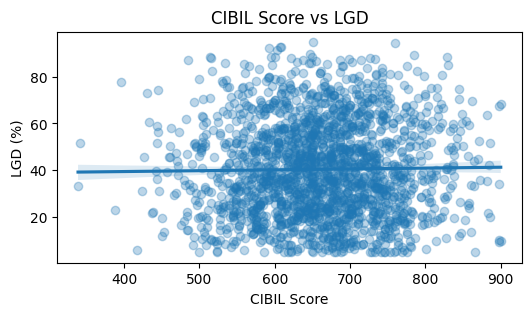

In [67]:
# Scatter Plot with Regression Line
plt.figure(figsize=(6,3))

sns.regplot(
    data=default_loans,
    x='cibil_score',
    y='lgd_pct',
    scatter_kws={'alpha':0.3}
)

plt.title('CIBIL Score vs LGD')
plt.xlabel('CIBIL Score')
plt.ylabel('LGD (%)')

plt.show()

A Pearson correlation coefficient of r = 0.016 means there is virtually no linear relationship between cibil_score and lgd_pct.

Interpretation :
The value is positive, but extremely close to zero.
As CIBIL score increases, LGD shows almost no consistent increase or decrease.
The relationship is so weak that it has little practical predictive value.

The Pearson correlation coefficient between CIBIL score and LGD percentage is 0.016, indicating an extremely weak positive relationship. This suggests that a borrower's credit score has almost no linear association with the severity of loss incurred after default. While CIBIL score may be useful for predicting the probability of default, it does not appear to be an effective standalone predictor of loss given default (LGD), and additional variables such as collateral value, recovery amount, and loan characteristics are likely required to explain LGD variation.